# Data Cleaning for evolution of electric cars

### Import Packages

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
pio.renderers.default = "notebook"
import os
os.getcwd()

'/Users/alinaloacker/Documents/GitHub/Data_Science_Project'

### Load Data
You need to download the following file: https://www.dropbox.com/scl/fi/q3ei8expvumspa6gaii17/cars_total-ev.csv?rlkey=281ft04hxha9fi2jp7hfr3jjo&st=4efbs54j&dl=0

In [104]:
df_cars_complete = pd.read_csv("cars_total-ev.csv")
df_cars_complete.head()


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,mot_nrg,Motor energy,geo,...,TIME_PERIOD,Time,leg_form,Legal form,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2016,NaN,TOTAL,Total,13,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2017,NaN,TOTAL,Total,48,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2018,NaN,TOTAL,Total,102,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2019,NaN,TOTAL,Total,124,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2020,NaN,TOTAL,Total,362,NaN,NaN,NaN,NaN,NaN


### Restructure dataset

In [106]:
print(df_cars_complete.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'Unit of measure', 'mot_nrg', 'Motor energy', 'geo', 'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'leg_form', 'Legal form', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


In [107]:
#Modyfiyng data set to only keep the variables I want, rename the remaining columns and get rid of the 2025 data
df_cars= (
    df_cars_complete[
        ["Geopolitical entity (reporting)",
            "TIME_PERIOD",
            "Motor energy",
            "OBS_VALUE" ]]
    .rename(columns={
        "Geopolitical entity (reporting)": "Country",
        "TIME_PERIOD": "Year",
        "Motor energy": "Index",
        "OBS_VALUE": "Cars"
    })
    .query("Year <= 2024")
    .pivot_table(
        index=["Country", "Year"],
        columns="Index",
        values="Cars"
    )
    .reset_index()
)

df_cars.head(10)

Index,Country,Year,Electricity,Total
0,Albania,2016,13.0,435613.0
1,Albania,2017,48.0,417426.0
2,Albania,2018,102.0,460027.0
3,Albania,2019,124.0,499590.0
4,Albania,2020,362.0,539497.0
5,Albania,2021,624.0,593280.0
6,Albania,2022,1245.0,639379.0
7,Albania,2023,2891.0,699337.0
8,Albania,2024,5722.0,775217.0
9,Austria,2016,9073.0,4821557.0


### Add the relative share of electric cars to the data-table

In [108]:
#next I want to add a column that shows the share of electric cars in the total number of cars
df_cars["EV_share"] = (df_cars["Electricity"] /
    df_cars["Total"] * 100)
df_cars.head(10)

Index,Country,Year,Electricity,Total,EV_share
0,Albania,2016,13.0,435613.0,0.002984
1,Albania,2017,48.0,417426.0,0.011499
2,Albania,2018,102.0,460027.0,0.022173
3,Albania,2019,124.0,499590.0,0.024820
4,Albania,2020,362.0,539497.0,0.067100
5,Albania,2021,624.0,593280.0,0.105178
6,Albania,2022,1245.0,639379.0,0.194720
7,Albania,2023,2891.0,699337.0,0.413392
8,Albania,2024,5722.0,775217.0,0.738116
9,Austria,2016,9073.0,4821557.0,0.188176


### Removing rows with no values for Electricity or Total

In [109]:
#check whether I have missing values
df_cars.isna().sum() #some missing values in electricity
df_cars[(df_cars['Electricity'].isna())] #for the moment, they don't matter, as I am not planning to use this countries for our analysis...
df_cars = df_cars.dropna()

### Filtering countries

In [116]:
considered_countries = ["Norway", "Sweden"]
df_cars_filtered = df_cars[df_cars["Country"].isin(considered_countries)]
df_cars_filtered
df_cars_filtered.isna().sum() #I have no missing values :)

Index
Country        0
Year           0
Electricity    0
Total          0
EV_share       0
dtype: int64

In [ ]:
### Univariate analysis

### Absolute amount of cars in considered countries (total and electric)

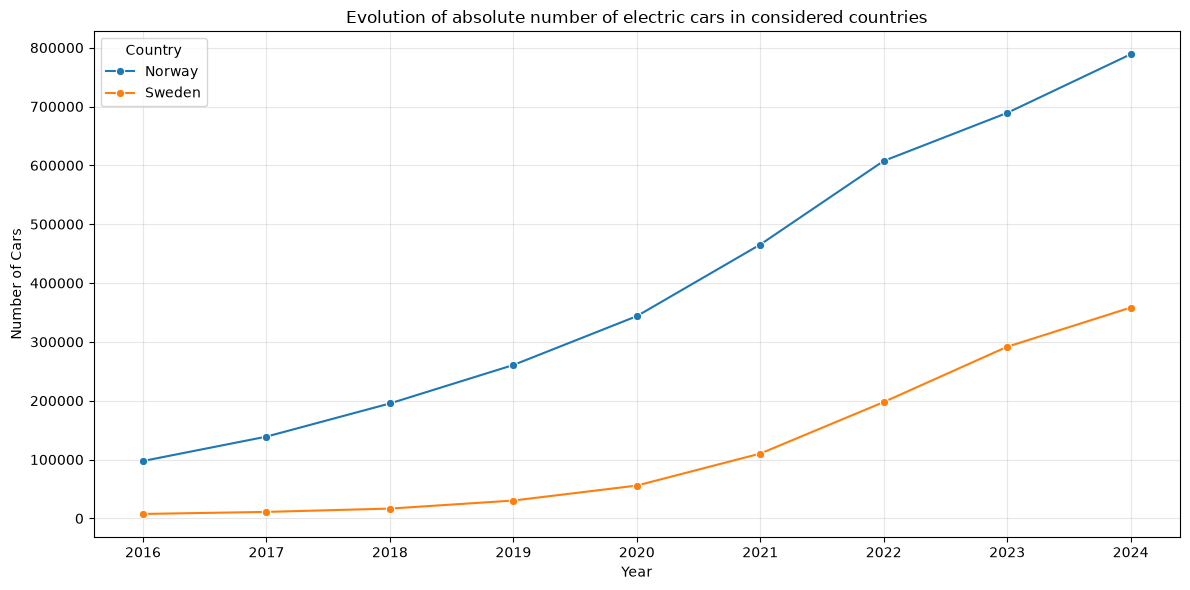

In [117]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_filtered,
    x="Year",
    y="Electricity",
    hue="Country",
    marker="o"
)

plt.title("Evolution of absolute number of electric cars in considered countries")
plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

### Relative amount of cars in considered countries (total and electric)

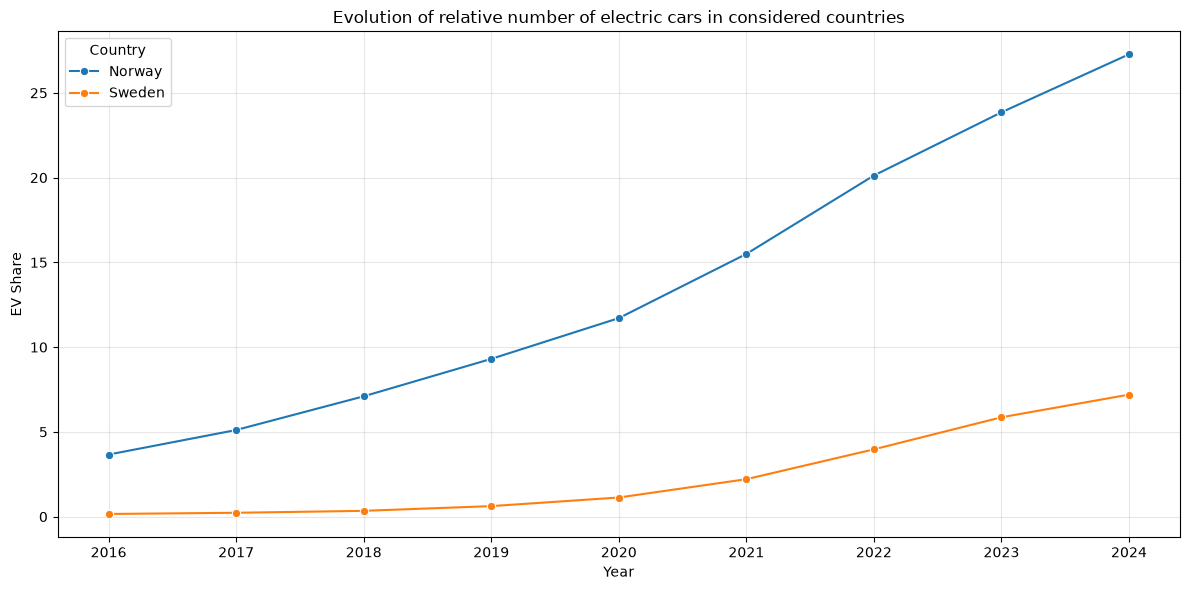

In [118]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_filtered,
    x="Year",
    y="EV_share",
    hue="Country",
    marker="o"
)

plt.title("Evolution of relative number of electric cars in considered countries")
plt.xlabel("Year")
plt.ylabel("EV Share")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()